In [ ]:
#https://github.com/intelligence-csd-auth-gr/Interpretable-Unsupervised-Learning/blob/main/LXDR/Quantitative%20analysis/Quantitative.ipynbfrom 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import pickle
import umap

from lxdr import LXDR
from sklearn.manifold import Isomap
from sklearn.datasets import fetch_openml
from tqdm import tqdm
from collections import Counter

In [2]:
%load_ext autoreload
%autoreload 2
import matplotlib
print(matplotlib.__version__)

3.6.3


In [8]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
X_scaled=X/255.0
train=X_scaled[:100]
labels_train=y[:100]
test=X_scaled[1000:1500]
labels_test=y[1000:1500]

feature_names=[str(i) for i in range(784)]

In [4]:
### fix this
def global_overlay_features(weights_list, title, top_k=10):
     '''
    This function colors the top k pixels with the highest magnitude of 
    feature attribution values on top of the averaged grayscaled image of each digit class. 
    This function shows global attribution.
    
    Input: 
        fa_avg_values: a list of 10 lists of averaged feature attribution values for each digit class 
        title: str; title for the figure
        top_k: int; how many pixels to color
    Output:
        Displays a 5 by 2 plot of gray scaled digits 0-9 with colored pixels.
    '''
    
    fig, ax=plt.subplots(2,5,figsize=(10,5))
    for i in range(10):
        weight_val=weights_list[i]
        og_image=train[labels_train==str(i)].mean(axis=0).reshape(28,28)
        
        top_indices=np.argsort(np.abs(weight_val), axis=None)[-top_k:]
        top_y,top_x=np.unravel_index(top_indices,(28,28))

        colors=np.zeros((28,28,3), dtype=float)
        for y,x in zip(top_y,top_x):
            if weight_val[y*28+x]>0:
                colors[y,x]=[1,0,0]  #red if avg attribution positive
            else:
                colors[y,x]=[0,0,1]  #blue if avg attribution negative
        ax[i//5, i%5].imshow(og_image, cmap="gray")
        ax[i//5, i%5].imshow(colors, alpha=0.6)
        ax[i//5, i%5].axis("off")
    fig.suptitle(title)

def heatmap_features(weight_values_avg, title):
    '''
    This function plots a heatmap of the global feature attribution values
    Input: 
        fa_values: a list of 10 lists of averaged feature attribution values for each digit class
        title: str; title for the figure
    Output:
        Displays a 5 by 2 heatmap plot of global feature attribution values.
    '''
    
    fig, ax=plt.subplots(2,5,figsize=(10,5))
    for i in range(10):
        weight_val=weight_values_avg[i]/np.sum(weight_values_avg[i])
        
        ax[i//5, i%5].imshow(weight_val.reshape(28,28),cmap="turbo")
        ax[i//5, i%5].axis("off")
    fig.suptitle(title)

In [9]:
### train isomap 
iso=Isomap(n_components=2)
iso_git=iso.fit_transform(train)

In [10]:
### train lxdr
lxdr_iso=LXDR(iso, 
              feature_names,
              train,
              use_shap=True,
              n_jobs=3)
lxdr_iso.type="locallocal"
lxdr_iso._set_knn_local()    

In [ ]:
n=train.shape[1]
lx_values_list_l2=[np.zeros(n) for _ in range(10)]

### by label
for ind, i in tqdm(enumerate(labels_train)):
    weights=lxdr_iso.explain_instance(train[ind])

    l2=np.sqrt(np.square(weights[0]) + np.square(weights[1]))
    lx_values_list_l2[int(i)]+=l2

In [12]:
for i in range(10):
    lx_values_list_l2[i]/=list(labels_train).count(str(i))

In [52]:
with open("./iso_weights_lat.pkl",'wb') as file:
    pickle.dump(iso_weights, file)

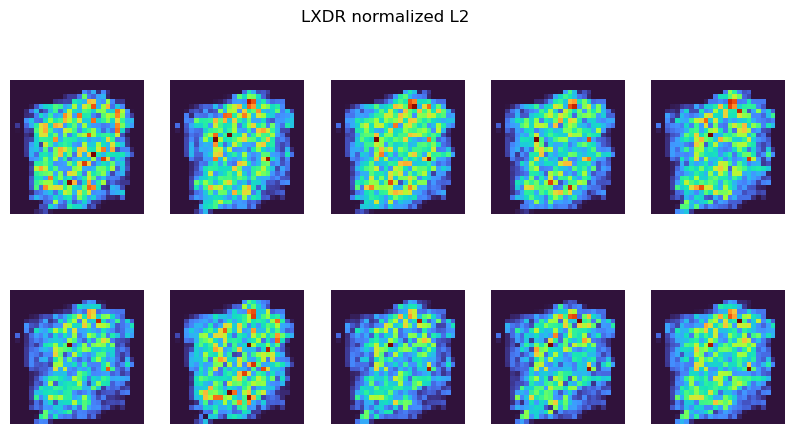

In [13]:
heatmap_features(lx_values_list_l2,"LXDR normalized L2")